# ANALYSIS

Our hypothesis posits that the vocabulary used to describe men and women is converging, suggesting that over time, the discourse surrounding women has become increasingly similar to that of men (in terms of highlighted achievements, virtues, and social roles). To test this, we divided the dataset by year of death and fitted a year-specific TF-IDF vectorizer to create an adjusted vocabulary for each period. Subsequently, we generated two distinct centroid vectors (mean Document-Term Matrices) for men and women per year. Finally, we computed the cosine similarity between these vectors annually. This provides a longitudinal measure of the semantic proximity between gendered discourses, reflecting how society's values regarding men and women have evolved toward convergence.

NEEDD TO THINK IF THERE COULD BE SOME CONFOUNDER IN GENDER -> ORBITUARY IF WE ARE CONTROLLING FOR YEAR. IF AGE IS NOT (WE CAN ASSUME THAT YPPUNG PEOPLE DYING IS THE SAME MEN AND WOMEN)

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression

Create the variable year so that we can know the death year directly.

In [98]:
df = pd.read_pickle("obituaries_lemma.pkl")
df['year'] = pd.to_datetime(df['date']).dt.year

Year 2001: Calculated similarity = 0.7736
Year 2002: Calculated similarity = 0.8234
Year 2003: Calculated similarity = 0.8253
Year 2004: Calculated similarity = 0.8081
Year 2005: Calculated similarity = 0.8090
Year 2006: Calculated similarity = 0.8137
Year 2007: Calculated similarity = 0.8115
Year 2008: Calculated similarity = 0.8223
Year 2009: Calculated similarity = 0.8363
Year 2010: Calculated similarity = 0.8492
Year 2011: Calculated similarity = 0.8496
Year 2012: Calculated similarity = 0.8664
Year 2013: Calculated similarity = 0.8681
Year 2014: Calculated similarity = 0.8774
Year 2015: Calculated similarity = 0.8779
Year 2016: Calculated similarity = 0.8885
Year 2017: Calculated similarity = 0.8730
Year 2018: Calculated similarity = 0.8825
Year 2019: Calculated similarity = 0.8677
Year 2020: Calculated similarity = 0.8730
Year 2021: Calculated similarity = 0.8696
Year 2022: Calculated similarity = 0.8655
Year 2023: Calculated similarity = 0.8739
Year 2024: Calculated similarity =

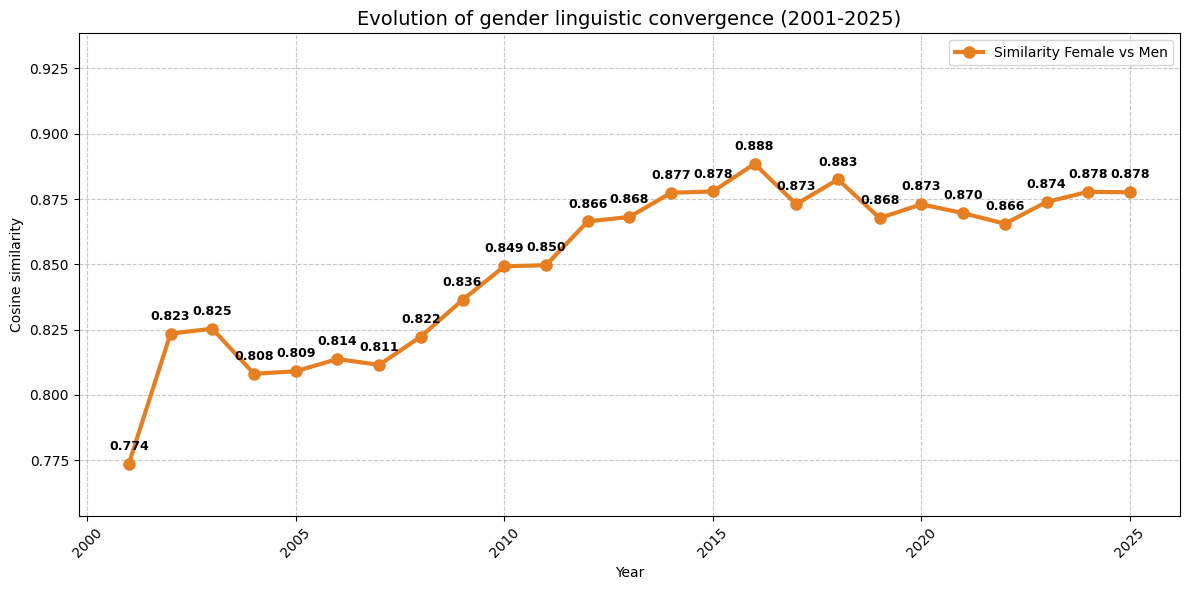

In [99]:
years = list(range(2001, 2026))
similarity_results = []


for i in years:
    
    df_year = df[df['year'] == i]
    text_m = df_year[df_year['gender'] == 'M']['text_clean']
    text_f = df_year[df_year['gender'] == 'F']['text_clean']
    
    if len(text_m) > 0 and len(text_f) > 0:
        # We create an specific TF-IDF for this year 
        vectorizer = TfidfVectorizer(max_df=0.4, min_df=2)
        vectorizer.fit(df_year['text_clean'])
        
        # We transfirm all the texts, and then create the "Mean Vector" for each gender. 
        tfidf_m = vectorizer.transform(text_m).mean(axis=0)
        tfidf_f = vectorizer.transform(text_f).mean(axis=0)
        
        # We compute the cosine similarity
        sim = cosine_similarity(np.asarray(tfidf_m), np.asarray(tfidf_f))[0][0]
        
        similarity_results.append({
            'Year': i,
            'Similarity': sim
        })
        print(f"Year {i}: Calculated similarity = {sim:.4f}")

# Ploting the results
df_res = pd.DataFrame(similarity_results)

if df_res.empty:
    print("Error: No data to plot.")
else:
    plt.figure(figsize=(12, 6))
    plt.plot(df_res['Year'], df_res['Similarity'], 
             marker='o', color='#e67e22', linewidth=3, markersize=8, label='Similarity Female vs Men')

    for i, row in df_res.iterrows():
        plt.annotate(f"{row['Similarity']:.3f}", 
                     (row['Year'], row['Similarity']), 
                     textcoords="offset points", 
                     xytext=(0,10), 
                     ha='center', 
                     fontweight='bold',
                     fontsize=9)

    plt.title('Evolution of gender linguistic convergence (2001-2025)', fontsize=14)
    plt.ylabel('Cosine similarity')
    plt.xlabel('Year')
    

    plt.ylim(df_res['Similarity'].min() - 0.02, df_res['Similarity'].max() + 0.05)
    
    plt.xticks(rotation=45) 
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

These results reveal a positive global trend that remains consistent across most yearly intervals, suggesting that the vocabularies used for men and women are progressively converging. To move beyond visual observation and ensure the statistical significance of this trend, we will perform a linear regression analysis on the similarity scores. This will allow us to quantify the rate of convergence and determine whether the observed narrowing of the linguistic gap is statistically robust or merely a product of annual variance.

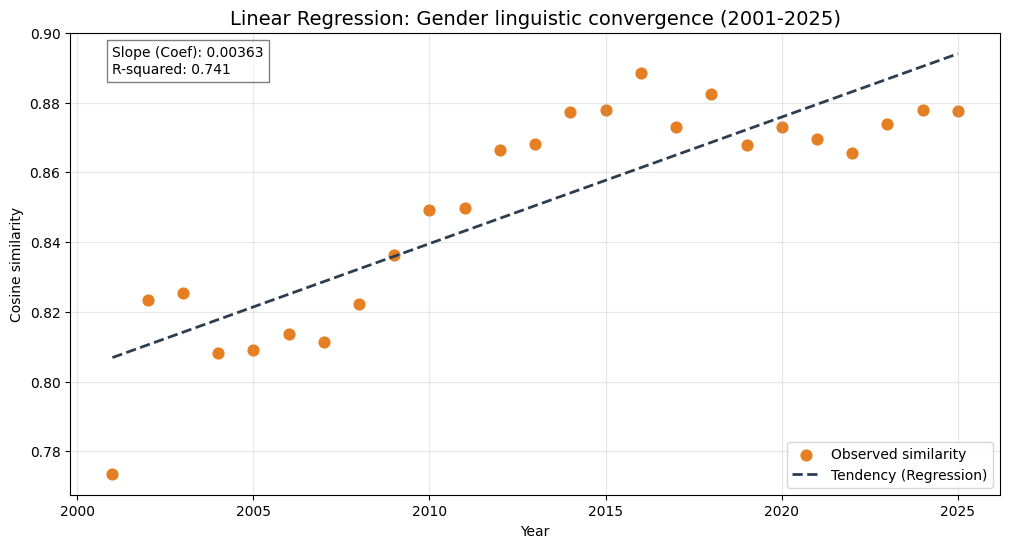

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.730
Method:                 Least Squares   F-statistic:                     65.84
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           3.36e-08
Time:                        22:38:12   Log-Likelihood:                 68.749
No. Observations:                  25   AIC:                            -133.5
Df Residuals:                      23   BIC:                            -131.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.4558      0.900     -7.170      0.0

In [100]:
X = np.array(df_res['Year']).reshape(-1, 1).astype(float)
y = df_res['Similarity'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
X_stat = sm.add_constant(X) 
model_stat = sm.OLS(y, X_stat).fit()

# Plotting the results
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='#e67e22', label='Observed similarity', s=60)
plt.plot(X, y_pred, color='#2c3e50', linestyle='--', linewidth=2, label='Tendency (Regression)')

plt.title('Linear Regression: Gender linguistic convergence (2001-2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Cosine similarity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.text(X.min(), y.max(), f"Slope (Coef): {model.coef_[0]:.5f}\nR-squared: {model_stat.rsquared:.3f}", 
         bbox=dict(facecolor='white', alpha=0.5))

plt.show()

# Show the statistical summary
print(model_stat.summary())

The linear regression analysis provides conclusive evidence of a sustained linguistic convergence between the male and female datasets from 2001 to 2025. The model yields a coefficient of 0.0036 for the time variable ($x_1$), indicating that the cosine similarity between gendered discourses increases by an average of 0.36% every year. This positive slope is highly significant ($p < 0.001$), allowing us to reject the null hypothesis of linguistic stability with a high degree of confidence ($t = 8.114$).

Furthermore, the model exhibits a remarkably high R-squared value of 0.741, suggesting that the passage of time alone explains 74.1% of the variance in the similarity scores. This indicates that the convergence is not merely a series of isolated fluctuations, but a robust and predictable long-term trend. Although the Durbin-Watson statistic (0.673) suggests the presence of positive autocorrelation—which is expected in longitudinal linguistic data where vocabulary changes incrementally—the overall strength of the F-statistic (65.84) confirms the model's high explanatory power.

In conclusion, these results demonstrate a significant shift in social discourse: the traditional linguistic boundaries that once defined how men and women were described are steadily eroding, leading toward a more unified and neutral descriptive framework.

To identify the specific areas driving this trend, we will analyze the convergence across four distinct thematic categories: Family, Professional, Religion, and Lifestyle. By constructing specialized lexicons for each domain, we aim to determine which of these dimensions show the highest rate of linguistic assimilation and which ones remain gender-segregated.

In [104]:
themes = {
    'Religion': set([
        'church', 'faith', 'god', 'jesus', 'christ', 'lord', 'pastor', 'reverend', 
        'priest', 'bible', 'scripture', 'catholic', 'baptist', 'methodist', 
        'christian', 'faithfully', 'heaven', 'blessed', 'prayer', 'pray', 
        'ministry', 'choir', 'spirit', 'spiritual', 'soul', 'devout', 'parish',
        'mass', 'vatican', 'amen', 'worship', 'congregation', 'clerical'
    ]),
    'Professional': set([
        'career', 'retired', 'worked', 'employed', 'professor', 'teacher', 
        'engineer', 'manager', 'director', 'business', 'company', 'university', 
        'degree', 'graduated', 'college', 'professional', 'owner', 'founder', 
        'department', 'industry', 'office', 'corporation', 'executive', 'nurse',
        'doctor', 'military', 'veteran', 'served', 'army', 'navy', 'position'
    ]),
    'Family': set([
        'family', 'mother', 'father', 'son', 'daughter', 'brother', 'sister',
        'grandchild', 'grandchildren', 'grandson', 'granddaughter', 'grandmother',
        'grandfather', 'nana', 'papa', 'niece', 'nephew', 'cousin', 'aunt', 'uncle',
        'husband', 'wife', 'spouse', 'partner', 'loving', 'beloved', 'devoted',
        'survived', 'children', 'great-grandchildren', 'parent'
    ]),
    'Lifestyle': set([
        'travel', 'traveled', 'journey', 'adventure', 'hiking', 'sailing', 'golf', 
        'gardening', 'cooking', 'music', 'concerts', 'art', 'reading', 'books', 
        'nature', 'outdoors', 'animals', 'dogs', 'cats', 'pets', 'beach', 'lake',
        'traveling', 'passion', 'enjoyed', 'hobbies', 'photography', 'sports', 
        'fan', 'watching', 'food', 'wine', 'restaurant', 'club', 'fishing', 
        'camping', 'collector', 'painting', 'dance', 'dancing', 'volunteering'
    ])
}

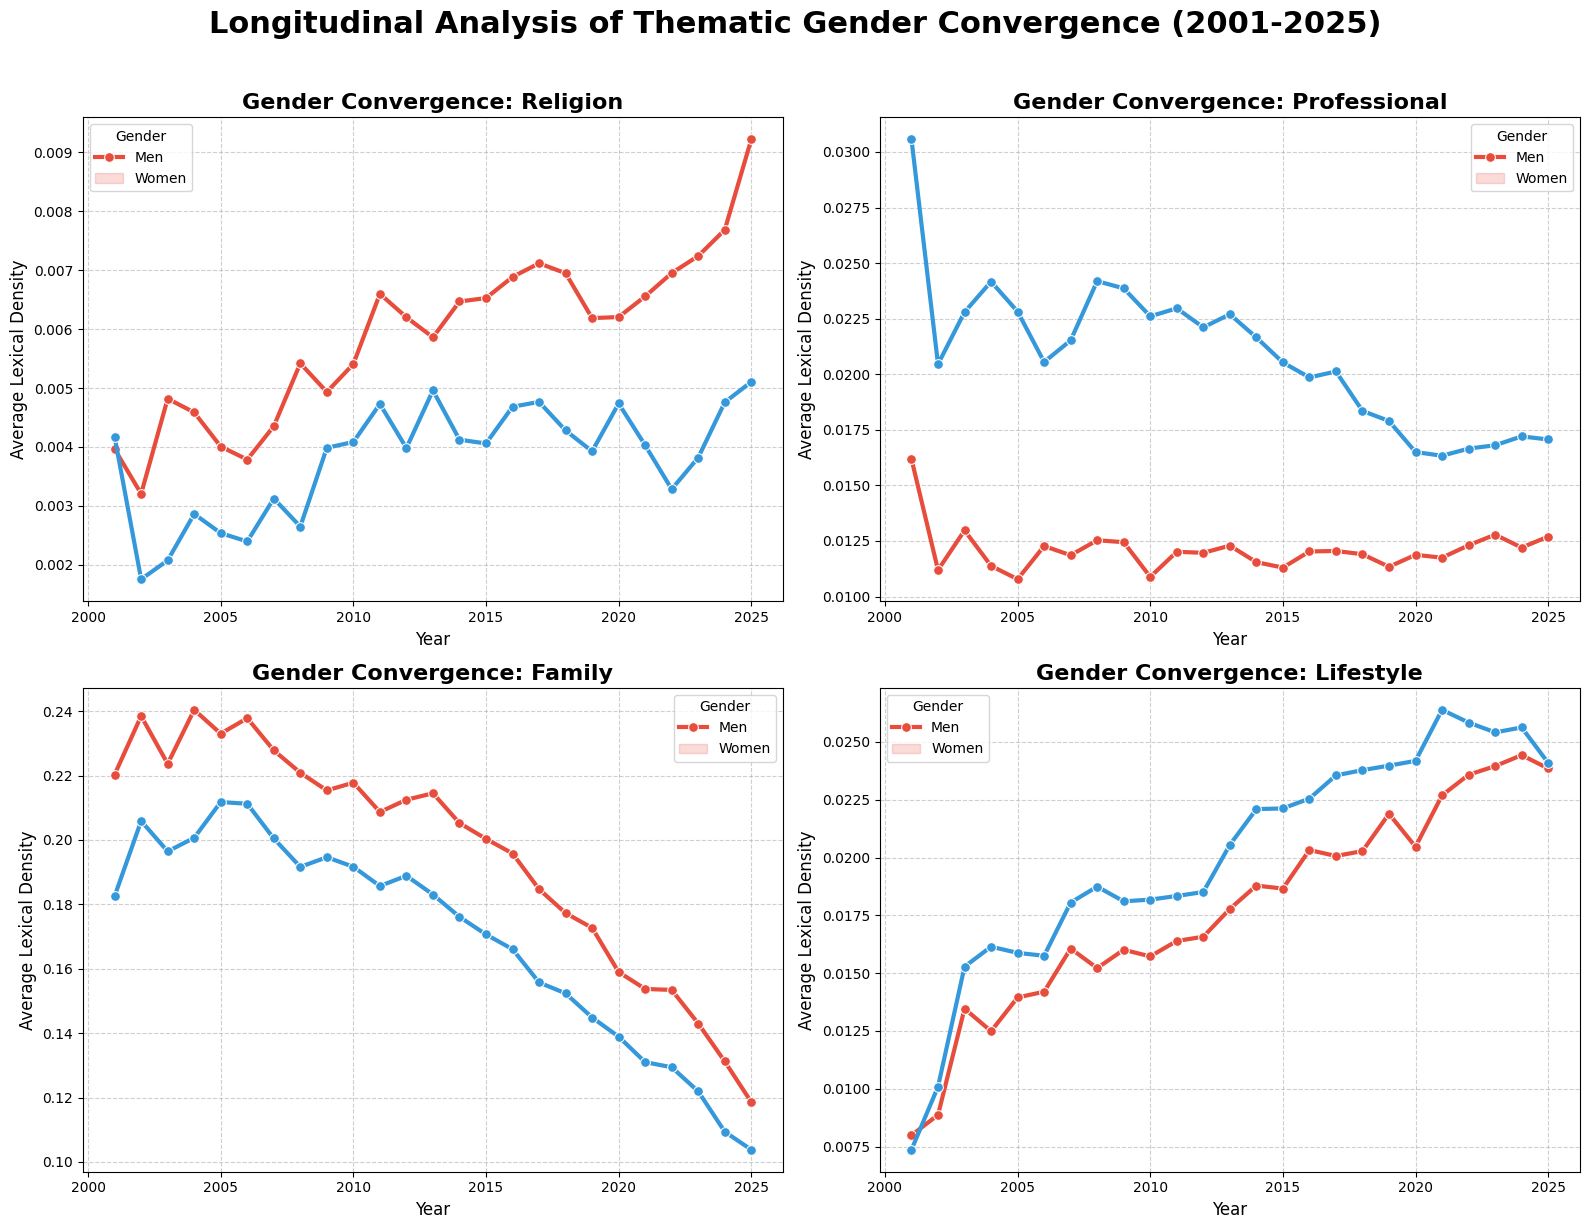

In [106]:

def get_density(text, word_set):
    if not isinstance(text, str): return 0
    tokens = text.lower().split()
    if not tokens: return 0
    return sum(1 for word in tokens if word in word_set) / len(tokens)

for name, word_set in themes.items():
    df[name] = df['text_clean'].apply(lambda x: get_density(x, word_set))


evolution = df.groupby(['year', 'gender'])[list(themes.keys())].mean().reset_index()
categories = list(themes.keys())
gender_colors = {'M': '#3498db', 'F': '#e74c3c'} 

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sns.lineplot(
        data=evolution, 
        x='year', 
        y=cat, 
        hue='gender', 
        ax=axes[i], 
        palette=gender_colors,
        linewidth=3,
        marker='o',
        markersize=7
    )
    
    axes[i].set_title(f'Gender Convergence: {cat}', fontsize=16, fontweight='bold')
    axes[i].set_ylabel('Average Lexical Density', fontsize=12)
    axes[i].set_xlabel('Year', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend(title='Gender', labels=['Men', 'Women'])

plt.suptitle('Longitudinal Analysis of Thematic Gender Convergence (2001-2025)', 
             fontsize=22, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()
